<a href="https://colab.research.google.com/github/adtapiagonzalez/PracticasRedesNeuronales_Adrian_Tapia/blob/main/PRACTICA_05_Adrian_Tapia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>05. Ajuste de la red</b></font>

# **Adrián Manuel Tapia González**
# adtapia@ucm.es

# Ejercicio 1
Crea un MLP que realice una clasificación razonable, para ello utiliza las estrategias ***que consideres oportunas***.

In [ ]:
# Elimina todas las variables definidas en el entorno actual
%reset -f

In [ ]:
# Se cargan los paquetes necesarios
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## Conexión a la GPU T4

Como primera estrategia, se decide **conectarse a una GPU** para servirse de la mayor potencia posible disponible en la GPU T4

In [ ]:
# Comprobamos si tenemos GPU
import torch
print(torch.cuda.is_available())  # Salida: True si hay una GPU disponible

True


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


Como sale cuda, se empleará la GPU como dispositvio de cálculo

In [ ]:
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')


Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


Por lo tanto, está conectado a la GPU T4

## Descarga y preparación de los datos

A continuación, se definen los datos. Se crearán **tres conjuntos de datos**: de entrenamiento, de validación y de evaluación

In [ ]:
class Flatten(object):
    def __call__(self, tensor):
        # Aplanar la imagen a un vector de 784 píxeles
        return tensor.view(-1)


transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte la imagen a tensor
    transforms.Normalize((0.5,), (0.5,)),  # Normalización
    transforms.Lambda(lambda x: x.view(-1)) # Aplanar las imágenes a un vector de 784 píxeles
    # Flatten()  # Aplanar las imágenes a un vector de 784 píxeles
])

# Se crea un conjunto de datos para el entrenamiento
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Se crea un conjunto de datos para la validación. Se empleará más adelante para Optuna
dev_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Se crea un conjunto de datos para la evaluación del modelo
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 29.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.28MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.50MB/s]


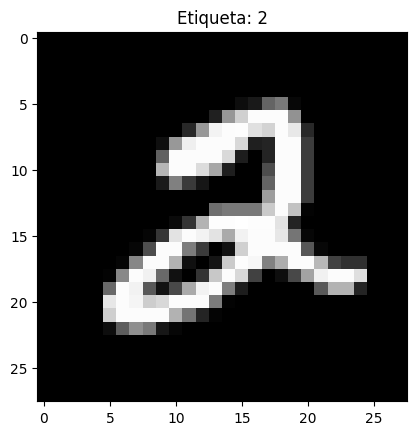

In [ ]:
image, label = train_dataset[5]  # Obtener la primera imagen del conjunto de entrenamiento

plt.imshow(image.view(28,28), cmap='gray')  # .squeeze() elimina la dimensión de los canales (1,28,28 -> 28,28)
plt.title(f"Etiqueta: {label}")
plt.show()

Se crean los dataloaders, empleando **mini-batches** como estrategia para el descenso de gradiente

In [ ]:
dataloader_train = DataLoader(train_dataset, batch_size = 64, shuffle = True) # Mini-batch de 64
dataloader_dev = DataLoader(dev_dataset, batch_size = 64, shuffle = True)
dataloader_test = DataLoader(test_dataset, batch_size = 64, shuffle = True)

## Búsqueda de hiper-parámetros con Optuna

Se emplea **Optuna** para buscar los mejores hiper-parámetros para el modelo propuesto

In [ ]:
!pip install torcheval
!pip install optuna

In [ ]:
# Se cargan las librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from torch.utils.data import DataLoader, TensorDataset
from torcheval.metrics import MulticlassAccuracy

In [ ]:
# Se define un MLP específico para Optuna que acepta dropout_p como parámetro
class OptunaMLP(torch.nn.Module):
    def __init__(self, num_features, dropout_p, num_classes=10):
        super().__init__()

        self.all_layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_features, 300),
            torch.nn.BatchNorm1d(300),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_p),

            # 2nd hidden layer
            torch.nn.Linear(300, 100),
            torch.nn.BatchNorm1d(100),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_p),

            # output layer
            torch.nn.Linear(100, num_classes)
        )

    def forward(self, x):
        output = self.all_layers(x)
        return output

In [ ]:
# Se define la función objetivo para Optuna
def objective(trial):

    # Se definen los hiperparámetros a optimizar
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    dropout_rate = trial.suggest_uniform("dropout_rate", 0.1, 0.6)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)

    num_epochs_trial = 5 # Se usan 5 épocas por trial

    # Crear modelo con los hiperparámetros sugeridos
    model = OptunaMLP(num_features=784, dropout_p=dropout_rate, num_classes=10).to(device)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Métrica de precisión para evaluar el modelo a la GPU
    accuracy = MulticlassAccuracy().to(device)

    model.train()
    # Entrenamiento del modelo
    for epoch in range(num_epochs_trial):
        for batch_idx, (features, targets) in enumerate(dataloader_train):
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            output = model(features)
            loss = loss_fn(output, targets)
            loss.backward()
            optimizer.step()

    # Evaluar la precisión en el conjunto de desarrollo (o test)
    model.eval()
    with torch.no_grad():
        for features, targets in dataloader_dev: # Se usa dataloader_dev para la evaluación durante la búsqueda de hiperparámetros
            features = features.to(device)
            targets = targets.to(device)
            output = model(features)
            accuracy.update(output, targets)

    return accuracy.compute().item()

In [ ]:
study = optuna.create_study(direction="maximize")  # Se busca maximizar la precisión
study.optimize(objective, n_trials=10)  # Se prueban 10 combinaciones

# 🔹 Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", study.best_params)

[I 2026-03-16 15:54:13,133] A new study created in memory with name: no-name-7e9decbf-297b-43da-b406-b64e4653213e
/tmp/ipykernel_5348/2620300961.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/tmp/ipykernel_5348/2620300961.py:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform("dropout_rate", 0.1, 0.6)
/tmp/ipykernel_5348/2620300961.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform

Mejores hiperparámetros: {'learning_rate': 0.0016398866883916962, 'dropout_rate': 0.22128000250589683, 'weight_decay': 1.3081575202052808e-05}


Se encuentra que el mejor valor para el learning rate es 0.0016398866883916962; el mejor valor de dropout es 0.22128000250589683; y el mejor valor de weight decay (el lambda dos de la regularización L2) es 0.000013081575202052808. En consecuencia, son los valores que se emplearán para el MLP propuesto

/tmp/ipykernel_5348/1036994904.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

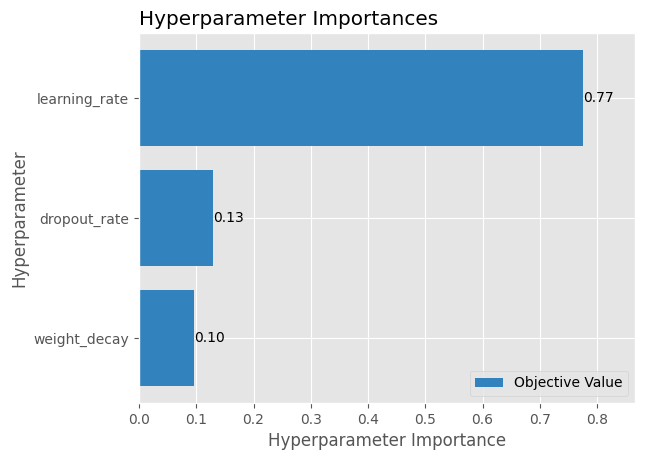

In [ ]:
optuna.visualization.matplotlib.plot_param_importances(study)

/tmp/ipykernel_5348/1455980257.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

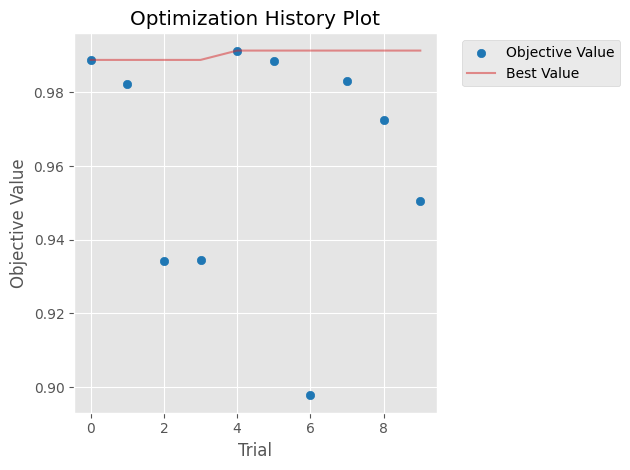

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)

## Definición de la red

### Dropout

Se decide emplear **dropout** para evitar que la red se sobreajuste a los datos de entrenamiento y sea más generalizable

In [ ]:
dropout_p = 0.22128000250589683 # Es el valor propuesto por Optuna

### Arquitectura de la red

Para la definición de la red, se tendrá en cuenta el dropout. Además, se añaden dos estrategias: **batch normalization** (1d, pues las imágenes se convierten en vectores de una dimensión) y **regularización L2** (weight decay en el **optimizador Adams**)

In [ ]:
import torch
!pip install torcheval

class MLP(torch.nn.Module):
    def __init__(self, num_features, num_classes=10):
        super().__init__()

        self.all_layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_features, 300), # 300 neuronas en la primera capa, al ser una tarea compleja
            torch.nn.BatchNorm1d(300), # Batch Normalization
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_p), # Se añade Dropout después de la primera capa oculta

            # 2nd hidden layer
            torch.nn.Linear(300, 100), # 100 neuronas en la segunda capa
            torch.nn.BatchNorm1d(100), # Batch Normalization
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_p), # Se añade Dropout después de la segunda capa oculta

            # output layer
            torch.nn.Linear(100, num_classes)
        )

    def forward(self, x):
        output = self.all_layers(x)
        return output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 5.3 MB/s eta 0:00:00


### Hiper-parámetros

In [ ]:
from torcheval.metrics import MulticlassAccuracy, MulticlassConfusionMatrix

# Se definen los hiper-parámetros

torch.manual_seed(1)

# num_features = 784 para MNIST y num_classes = 10
model = MLP(num_features=784, num_classes=10).to(device)

loss_fn = torch.nn.CrossEntropyLoss()

# Se añade weight_decay para la regularización L2
optimizer = torch.optim.Adam(model.parameters(), lr=0.0016398866883916962, weight_decay=0.000013081575202052808)

acc = MulticlassAccuracy() # Se calcula la precisión (accurary)
m_confusion = MulticlassConfusionMatrix(num_classes=10)


## Entrenamiento de la red

In [ ]:
num_epochs = 20 # 20 épocas de entrenamiento

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train() # Modo entrenamiento
    for batch_idx, (features, targets) in enumerate(dataloader_train): # Se usa dataloader_train

        # Se mueven los datos a la GPU
        features = features.to(device)
        targets = targets.to(device)

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Esto es algo especifico para la evaluacion, en cada epoca actualizamos:
        acc.update(output.cpu(), targets.cpu()) # Mover a CPU para torcheval si el modelo está en GPU

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            ### Imprimimos info
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(dataloader_train):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/020 | Batch 000/938 | Train Loss: 2.48 | Accuracy: 0.06
Epoch: 001/020 | Batch 100/938 | Train Loss: 0.70 | Accuracy: 0.74
Epoch: 001/020 | Batch 200/938 | Train Loss: 0.47 | Accuracy: 0.81
Epoch: 001/020 | Batch 300/938 | Train Loss: 0.63 | Accuracy: 0.84
Epoch: 001/020 | Batch 400/938 | Train Loss: 0.37 | Accuracy: 0.86
Epoch: 001/020 | Batch 500/938 | Train Loss: 0.29 | Accuracy: 0.87
Epoch: 001/020 | Batch 600/938 | Train Loss: 0.26 | Accuracy: 0.88
Epoch: 001/020 | Batch 700/938 | Train Loss: 0.15 | Accuracy: 0.88
Epoch: 001/020 | Batch 800/938 | Train Loss: 0.21 | Accuracy: 0.89
Epoch: 001/020 | Batch 900/938 | Train Loss: 0.29 | Accuracy: 0.90
Epoch: 002/020 | Batch 000/938 | Train Loss: 0.17 | Accuracy: 0.90
Epoch: 002/020 | Batch 100/938 | Train Loss: 0.15 | Accuracy: 0.90
Epoch: 002/020 | Batch 200/938 | Train Loss: 0.14 | Accuracy: 0.91
Epoch: 002/020 | Batch 300/938 | Train Loss: 0.39 | Accuracy: 0.91
Epoch: 002/020 | Batch 400/938 | Train Loss: 0.15 | Accuracy: 

## Evaluación del modelo

In [ ]:
model.eval() # Poner el modelo en modo de evaluación

all_preds = []
all_targets = []

with torch.no_grad(): # Se desactiva el cálculo de gradientes para la evaluación
    for features, targets in dataloader_test: # Se emplea el conjunto de datos de evaluación para evaluar el modelo
        features = features.to(device)
        targets = targets.to(device);

        outputs = model(features);

        _, predicted = torch.max(outputs, 1);

        all_preds.append(predicted.cpu());
        all_targets.append(targets.cpu());

# Se concatenan todos los tensores para el cálculo final de las métricas
all_preds = torch.cat(all_preds);
all_targets = torch.cat(all_targets);

# Se calcula la precisión
acc.update(all_preds, all_targets);
print(f"Accuracy on test set: {acc.compute().item():.4f}");

# Se calcula la matriz de confusión
m_confusion.update(all_preds, all_targets);
print("Confusion Matrix:");
print(m_confusion.compute());

Accuracy on test set: 0.9734
Confusion Matrix:
tensor([[9.7000e+02, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         3.0000e+00, 0.0000e+00, 2.0000e+00, 4.0000e+00],
        [0.0000e+00, 1.1270e+03, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         3.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00],
        [2.0000e+00, 3.0000e+00, 1.0150e+03, 1.0000e+00, 3.0000e+00, 0.0000e+00,
         0.0000e+00, 6.0000e+00, 2.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 3.0000e+00, 9.9600e+02, 0.0000e+00, 2.0000e+00,
         0.0000e+00, 3.0000e+00, 0.0000e+00, 6.0000e+00],
        [0.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00, 9.6200e+02, 0.0000e+00,
         4.0000e+00, 2.0000e+00, 2.0000e+00, 9.0000e+00],
        [2.0000e+00, 0.0000e+00, 0.0000e+00, 8.0000e+00, 0.0000e+00, 8.7500e+02,
         3.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00],
        [4.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 3.0000e+00,
         9.4500e+02, 0.0000e+00, 1.000

Con el objetivo de hacer la matriz de confusión más legible, se ha decidido emplear un heatmap para visualizarla adecuadamente

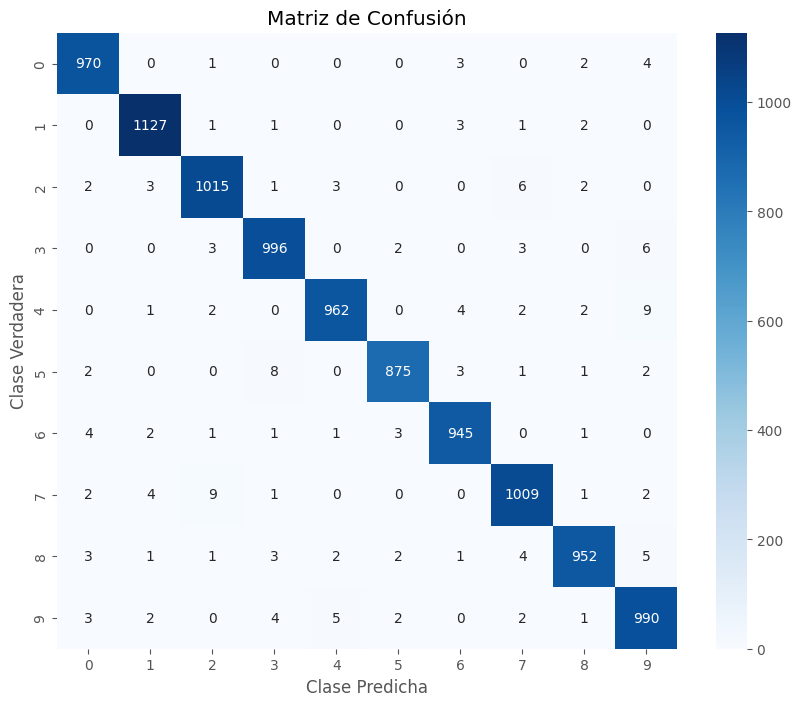

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se obtiene la matriz de confusión de torcheval.metrics
confusion_matrix_tensor = m_confusion.compute()

# Se convierte el tensor a un array numpy para visualización
confusion_matrix_np = confusion_matrix_tensor.numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_np, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión')
plt.show()

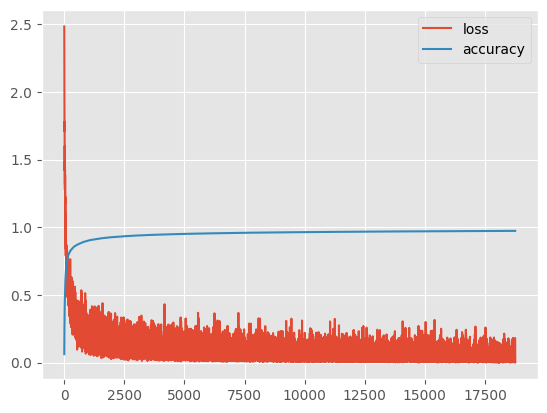

In [ ]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()


Como se puede observar, el modelo aprende a clasificar más que adecuadamente, llegando a una precisión de 0.97. Dado que la evaluación se ha hecho con un conjunto de datos distinto al del entrenamiento, se puede considerar un modelo más que adecuado para la clasificación de este tipo de imágenes.
Por su parte, el loss, aunque rebota un poco, tiene una convergencia cada vez más cercana a 0. Esto destaca la tendencia del modelo a tener cada vez menos error.

En conclusión, el modelo propuesto logra clasificar la gran mayoría de imágenes en sus respectivos números representados, puediendo emplearse para futuras tareas de clasificación con otros conjuntos de datos parecidos